In [1]:
%load_ext autoreload
%autoreload 2

import numpy as np
import matplotlib.pyplot as plt

from prism.prism_math.activation_coefs import get_alpha_coefs, compute_eta_error_tanh
from prism.prism_math.polynomials import polyval_cpu


In [2]:
alpha_coefs, exponents, alpha_coefs_float64 = get_alpha_coefs(
    function_type='tanh',
    big_m=10, v_max=2, dps=64,
    load_file=None, save=False, silent=True)

In [3]:
from mpmath import cos, exp, fabs, betainc, csch, factorial, fmul, gamma, \
    hyper, im, lerchphi, meijerg, polar, re, rect, sech, sqrt, sign, sin, tanh
from mpmath import mp
from mpmath import pi, inf, j
from mpmath import quad

mp.dps = 100

In [4]:
def compute_eta_error_tanh2(v_values, big_m, v_max):
    q = 2*big_m + 3
    tau = (factorial(q)) ** (1/q) / v_max

    eta_error_tanh = np.zeros(v_values.shape)

    for idx in range(0, len(v_values)):
        v = v_values[idx]

        integrand1 = lambda xi: \
            (xi*v)**(2*big_m + 3) * csch(pi/2*xi) \
            * hyper([1], [big_m+2, big_m+5/2], -(xi*v)**2.0/4.0)
        integral1 = quad(integrand1, [0, tau])

        integral2 = 2*np.tanh(v) \
            - j/pi * (betainc(1.0/2.0 + j*v/pi, 0, x1=0, x2=exp(pi*tau)) \
            - betainc(1.0/2.0 - j*v/pi, 0, x1=0, x2=exp(pi*tau)))

        eta_error_tanh[idx] = \
            (-1)**(big_m + 1)/factorial(2*big_m+3)*integral1 + re(integral2)

    return eta_error_tanh

In [5]:
def compute_eta_error_tanh3(v_values, big_m, v_max):
    q = 2*big_m + 3
    tau = (factorial(q)) ** (1/q) / v_max

    eta_error_tanh = np.zeros(v_values.shape)

    for idx in range(0, len(v_values)):
        v = v_values[idx]

        integrand1 = lambda xi: \
            (xi*v)**(2*big_m + 3) * csch(pi/2*xi) \
            * hyper([1], [big_m+2, big_m+5/2], -(xi*v)**2.0/4.0)
        integral1 = quad(integrand1, [0, tau])

        F1 = hyper([1, 1/2 + j*v/pi], [3/2 + j*v/pi], exp(pi*tau))
        F2 = hyper([1, 1/2 - j*v/pi], [3/2 - j*v/pi], exp(pi*tau))

        E1 = exp(pi*tau) ** (1/2 + j*v/pi) / (1/2 + j*v/pi)
        E2 = exp(pi*tau) ** (1/2 - j*v/pi) / (1/2 - j*v/pi)

        U1 =  E1 * F1
        U2 =  E2 * F2

        integral2 = 2*np.tanh(v) - j/pi * (U1 - U2)

        eta_error_tanh[idx] = \
            (-1)**(big_m + 1)/factorial(2*big_m+3)*integral1 + re(integral2)

    return eta_error_tanh

In [6]:
def compute_eta_error_tanh4(v_values, big_m, v_max):
    q = 2*big_m + 3
    tau = (factorial(q)) ** (1/q) / v_max

    eta_error_tanh = np.zeros(v_values.shape)

    for idx in range(0, len(v_values)):
        v = v_values[idx]

        integrand1 = lambda xi: \
            (xi*v)**(2*big_m + 3) * csch(pi/2*xi) \
            * hyper([1], [big_m+2, big_m+5/2], -(xi*v)**2.0/4.0)
        integral1 = quad(integrand1, [0, tau])

        F1 = hyper([1, 1], [3/2 - j*v/pi], 1/(1-exp(pi*tau)) ) \
            / ((exp(pi*tau) - 1)*(1/2 - j*v/pi)) \
            + pi*(-exp(pi*tau)) ** (-1/2 - j*v/pi) * sech(v)

        F2 = hyper([1, 1], [3/2 + j*v/pi], 1/(1-exp(pi*tau)) ) \
            / ((exp(pi*tau) - 1)*(1/2 + j*v/pi)) \
            + pi*(-exp(pi*tau)) ** (-1/2 + j*v/pi) * sech(v)

        E1 = exp(pi*tau) ** (1/2 + j*v/pi)
        E2 = exp(pi*tau) ** (1/2 - j*v/pi)

        U1 = fmul(E1, F1, exact=True) # Exact complex multiplication
        U2 = fmul(E2, F2, exact=True) # Exact complex multiplication

        integral2 = 2*np.tanh(v) - j/pi * (U1 - U2)

        eta_error_tanh[idx] = \
            (-1)**(big_m + 1)/factorial(2*big_m+3)*integral1 + re(integral2)

    return eta_error_tanh

In [7]:
def compute_eta_error_tanh5(v_values, big_m, v_max):
    q = 2*big_m + 3
    tau = (factorial(q)) ** (1/q) / v_max

    eta_error_tanh = np.zeros(v_values.shape)

    for idx in range(0, len(v_values)):
        v = v_values[idx]

        integrand1 = lambda xi: \
            (xi*v)**(2*big_m + 3) * csch(pi/2*xi) \
            * hyper([1], [big_m+2, big_m+5/2], -(xi*v)**2.0/4.0)
        integral1 = quad(integrand1, [0, tau])

        U1 = exp(tau*pi/2) * exp(j*tau*v) / ((exp(pi*tau) - 1)*(1/2 - j*v/pi)) \
            * hyper([1, 1], [3/2 - j*v/pi], 1/(1-exp(pi*tau)) ) \
            - j*pi * (tanh(v) + 1)

        U2 = exp(tau*pi/2) * exp(-j*tau*v) / ((exp(pi*tau) - 1)*(1/2 + j*v/pi)) \
            * hyper([1, 1], [3/2 + j*v/pi], 1/(1-exp(pi*tau)) ) \
            - j*pi * (1 - tanh(v))

        integral2 = 2*np.tanh(v) - j/pi * (U1 - U2)

        eta_error_tanh[idx] = \
            (-1)**(big_m + 1)/factorial(2*big_m+3)*integral1 + re(integral2)

    return eta_error_tanh

In [8]:
def compute_eta_error_tanh6(v_values, big_m, v_max):
    q = 2*big_m + 3
    tau = (factorial(q)) ** (1/q) / v_max

    eta_error_tanh = np.zeros(v_values.shape)

    for idx in range(0, len(v_values)):
        v = v_values[idx]

        integrand1 = lambda xi: \
            (xi*v)**(2*big_m + 3) * csch(pi/2*xi) \
            * hyper([1], [big_m+2, big_m+5/2], -(xi*v)**2.0/4.0)
        integral1 = quad(integrand1, [0, tau])

        U1 = exp(-j*tau*v) / (v - j*pi/2) \
            * hyper([1, 1], [3/2 + j*v/pi], 1/(1-exp(pi*tau)) )

        U2 = exp(j*tau*v) / (v + j*pi/2) \
            * hyper([1, 1], [3/2 - j*v/pi], 1/(1-exp(pi*tau)) )

        integral2 = exp(tau*pi/2) / (exp(pi*tau) - 1) * (U1 + U2)

        eta_error_tanh[idx] = \
            (-1)**(big_m + 1)/factorial(2*big_m+3)*integral1 + re(integral2)

    return eta_error_tanh

In [9]:
def compute_eta_error_tanh_approx_large_tau(v_values, big_m, v_max):
    q = 2*big_m + 3
    tau = (factorial(q)) ** (1/q) / v_max

    eta_error_tanh = np.zeros(v_values.shape)

    for idx in range(0, len(v_values)):
        v = v_values[idx]

        #integrand1 = lambda xi: \
        #    (xi*v)**(2*big_m + 3) * csch(pi/2*xi) \
        #    * hyper([1], [big_m+2, big_m+5/2], -(xi*v)**2.0/4.0)
        #integral1 = quad(integrand1, [0, tau])

        integral2 = 4*exp(tau*pi/2) / ((exp(pi*tau) - 1) * (4*v**2 + pi**2)) \
            * (pi*sin(tau*v) + 2*v*cos(tau*v))

        #integral2_complex = exp(tau*pi/2) / (exp(pi*tau) - 1) * (exp(-j*tau*v) / (v - j*pi/2) + exp(j*tau*v) / (v + j*pi/2))
        
        #integral_check = integral2 - integral2_complex
        #print(integral_check)

        #eta_error_tanh[idx] = \
        #    (-1)**(big_m + 1)/factorial(2*big_m+3)*integral1 + re(integral2)

        eta_error_tanh[idx] = re(integral2)

    return eta_error_tanh

In [15]:
v = np.arange(-2.1, 2.1, 0.1)
y = polyval_cpu(alpha_coefs_float64, exponents, v)
y_true = np.tanh(v)

errora = compute_eta_error_tanh_approx_large_tau(v, big_m=10, v_max=2)

error_true = y_true - y
error1 = compute_eta_error_tanh5(v, big_m=10, v_max=2)
error2 = compute_eta_error_tanh6(v, big_m=10, v_max=2)


Text(0, 0.5, 'log10(abs(coef))')

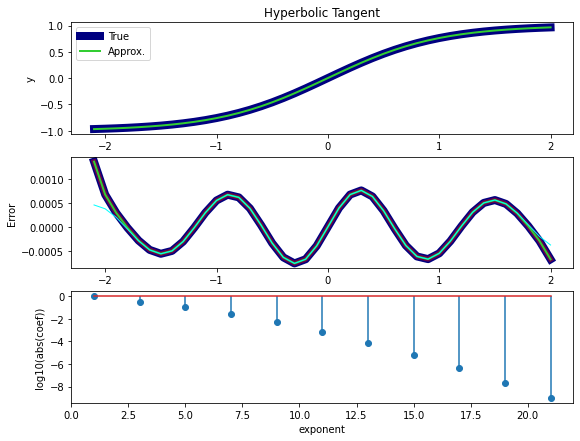

In [16]:
fig, axs = plt.subplots(3, 1, figsize=(9,7))
axs[0].plot(v, y_true, linewidth=8, color='navy')
axs[0].plot(v, y, linewidth=2, color='limegreen')
axs[0].set_xlabel('v')
axs[0].set_ylabel('y')
axs[0].set_title('Hyperbolic Tangent')
axs[0].legend(('True', 'Approx.'))
axs[1].plot(v, error1, linewidth=8, color='navy')
axs[1].plot(v, error_true, linewidth=5, color='r', alpha=0.4)
axs[1].plot(v, error2, linewidth=2, color='limegreen')
axs[1].plot(v, errora, linewidth=1, color='cyan')
axs[1].set_xlabel('v')
axs[1].set_ylabel('Error')
axs[2].stem(exponents, np.log10(np.abs(alpha_coefs_float64)))
axs[2].set_xlabel('exponent')
axs[2].set_ylabel('log10(abs(coef))')

In [12]:
error2

array([ 1.35865038e-03,  6.74327626e-04,  2.90169674e-04, -1.65508227e-05,
       -2.82963912e-04, -4.78276489e-04, -5.59318225e-04, -4.99731928e-04,
       -3.05000042e-04, -1.62713054e-05,  2.96422642e-04,  5.50151387e-04,
        6.70804965e-04,  6.15063882e-04,  3.86136942e-04,  3.75257884e-05,
       -3.38155489e-04, -6.33861896e-04, -7.59972811e-04, -6.73436275e-04,
       -3.93886905e-04,  7.35817201e-18,  3.93886905e-04,  6.73436275e-04,
        7.59972811e-04,  6.33861896e-04,  3.38155489e-04, -3.75257884e-05,
       -3.86136942e-04, -6.15063882e-04, -6.70804965e-04, -5.50151387e-04,
       -2.96422642e-04,  1.62713054e-05,  3.05000042e-04,  4.99731928e-04,
        5.59318225e-04,  4.78276489e-04,  2.82963912e-04,  1.65508227e-05,
       -2.90169674e-04, -6.74327626e-04])

In [13]:
q = 2*10 + 3
tau = (factorial(q)) ** (1/q) / pi/2

In [14]:
tau

mpf('1.500639628979471652039302467196829730087212711259333653619948777727849697632497611634882180755676298055')